## 1. Install Required Libraries

In [1]:
# Install YOLOv8 and required dependencies with CUDA support
# This installs PyTorch with CUDA 11.8 support
# !pip uninstall torch torchvision torchaudio -y
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install ultralytics opencv-python pandas matplotlib seaborn pillow pyyaml

## 2. Import Libraries

In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
from ultralytics import YOLO

cuda_available = torch.cuda.is_available()

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Dataset Exploration

In [2]:
# Define dataset paths
from pathlib import Path

# Load from the prepared dataset 4
dataset_root = Path('datasets/4')
annotations_dir = dataset_root / 'annotations'
images_dir = dataset_root / 'images'

train_split_images_dir = images_dir / 'train_split'
test_split_images_dir = images_dir / 'test_split'

dataset_structure = {
    'dataset_root': str(dataset_root)
}

if annotations_dir.exists():
    dataset_structure['annotations'] = sorted(item.name for item in annotations_dir.iterdir())

if images_dir.exists():
    dataset_structure['images'] = {
        item.name: len(list(item.glob('*')))
        for item in images_dir.iterdir()
        if item.is_dir()
    }

## 4. Load and Examine Annotations

In [3]:
# Function to load JSON annotations
import json
def load_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        return json.load(f)

def merge_coco_splits(coco_a, coco_b):
    return {
        'images': coco_a.get('images', []) + coco_b.get('images', []),
        'annotations': coco_a.get('annotations', []) + coco_b.get('annotations', []),
        'categories': coco_a.get('categories', coco_b.get('categories', []))
    }

def split_coco_by_filenames(coco_data, train_files, test_files):
    images = coco_data.get('images', [])
    annotations = coco_data.get('annotations', [])
    categories = coco_data.get('categories', [])

    image_id_to_name = {img['id']: Path(img.get('file_name', '')).name for img in images if 'id' in img}
    train_ids = {img_id for img_id, name in image_id_to_name.items() if name in train_files}
    test_ids = {img_id for img_id, name in image_id_to_name.items() if name in test_files}

    train_images = [img for img in images if img.get('id') in train_ids]
    test_images = [img for img in images if img.get('id') in test_ids]
    train_annotations = [ann for ann in annotations if ann.get('image_id') in train_ids]
    test_annotations = [ann for ann in annotations if ann.get('image_id') in test_ids]

    train_split = {'images': train_images, 'annotations': train_annotations, 'categories': categories}
    test_split = {'images': test_images, 'annotations': test_annotations, 'categories': categories}
    return train_split, test_split

def empty_coco(categories):
    return {'images': [], 'annotations': [], 'categories': categories}

# Detect annotation format
main_coco_path = annotations_dir / 'main.json'

if main_coco_path.exists():
    # Single-file COCO dataset format
    main_coco = load_annotations(main_coco_path)
    objects_all = main_coco
    rails_all = empty_coco(main_coco.get('categories', []))
    detected_annotation_format = 'single_coco_main_json'
else:
    raise FileNotFoundError(
        f'Unsupported annotation layout in {annotations_dir}. Expected main.json.'
    )

all_image_files = sorted({
    Path(img.get('file_name', '')).name
    for img in objects_all.get('images', [])
    if img.get('file_name')
})

# Use the full dataset with an 80/20 split
train_target_count = int(len(all_image_files) * 0.8)
test_target_count = len(all_image_files) - train_target_count

train_files = set(all_image_files[:train_target_count])
test_files = set(all_image_files[train_target_count:train_target_count+test_target_count])

objects_train, objects_val = split_coco_by_filenames(objects_all, train_files, test_files)
rails_train, rails_val = split_coco_by_filenames(rails_all, train_files, test_files)

# Materialize split images on disk
import shutil
for split_dir in [train_split_images_dir, test_split_images_dir]:
    split_dir.mkdir(parents=True, exist_ok=True)
    for existing_file in split_dir.glob('*'):
        if existing_file.is_file():
            existing_file.unlink()

source_image_dir = images_dir

def copy_split_images(file_names, destination_dir):
    missing_files = []
    for file_name in sorted(file_names):
        source_path = source_image_dir / file_name
        if not source_path.exists():
            matches = list(source_image_dir.rglob(file_name))
            source_path = matches[0] if matches else None
        if source_path is None or not source_path.exists():
            missing_files.append(file_name)
            continue
        shutil.copy2(source_path, destination_dir / file_name)
    return missing_files

missing_train_files = copy_split_images(train_files, train_split_images_dir)
missing_test_files = copy_split_images(test_files, test_split_images_dir)

annotation_overview = {
    'annotation_format': detected_annotation_format,
    'objects_train_annotations': len(objects_train.get('annotations', [])),
    'objects_test_annotations': len(objects_val.get('annotations', [])),
    'rails_train_annotations': len(rails_train.get('annotations', [])),
    'rails_test_annotations': len(rails_val.get('annotations', [])),
    'train_images_selected': len(train_files),
    'test_images_selected': len(test_files),
    'train_images_missing': len(missing_train_files),
    'test_images_missing': len(missing_test_files),
    'source_image_dir': str(source_image_dir)
}

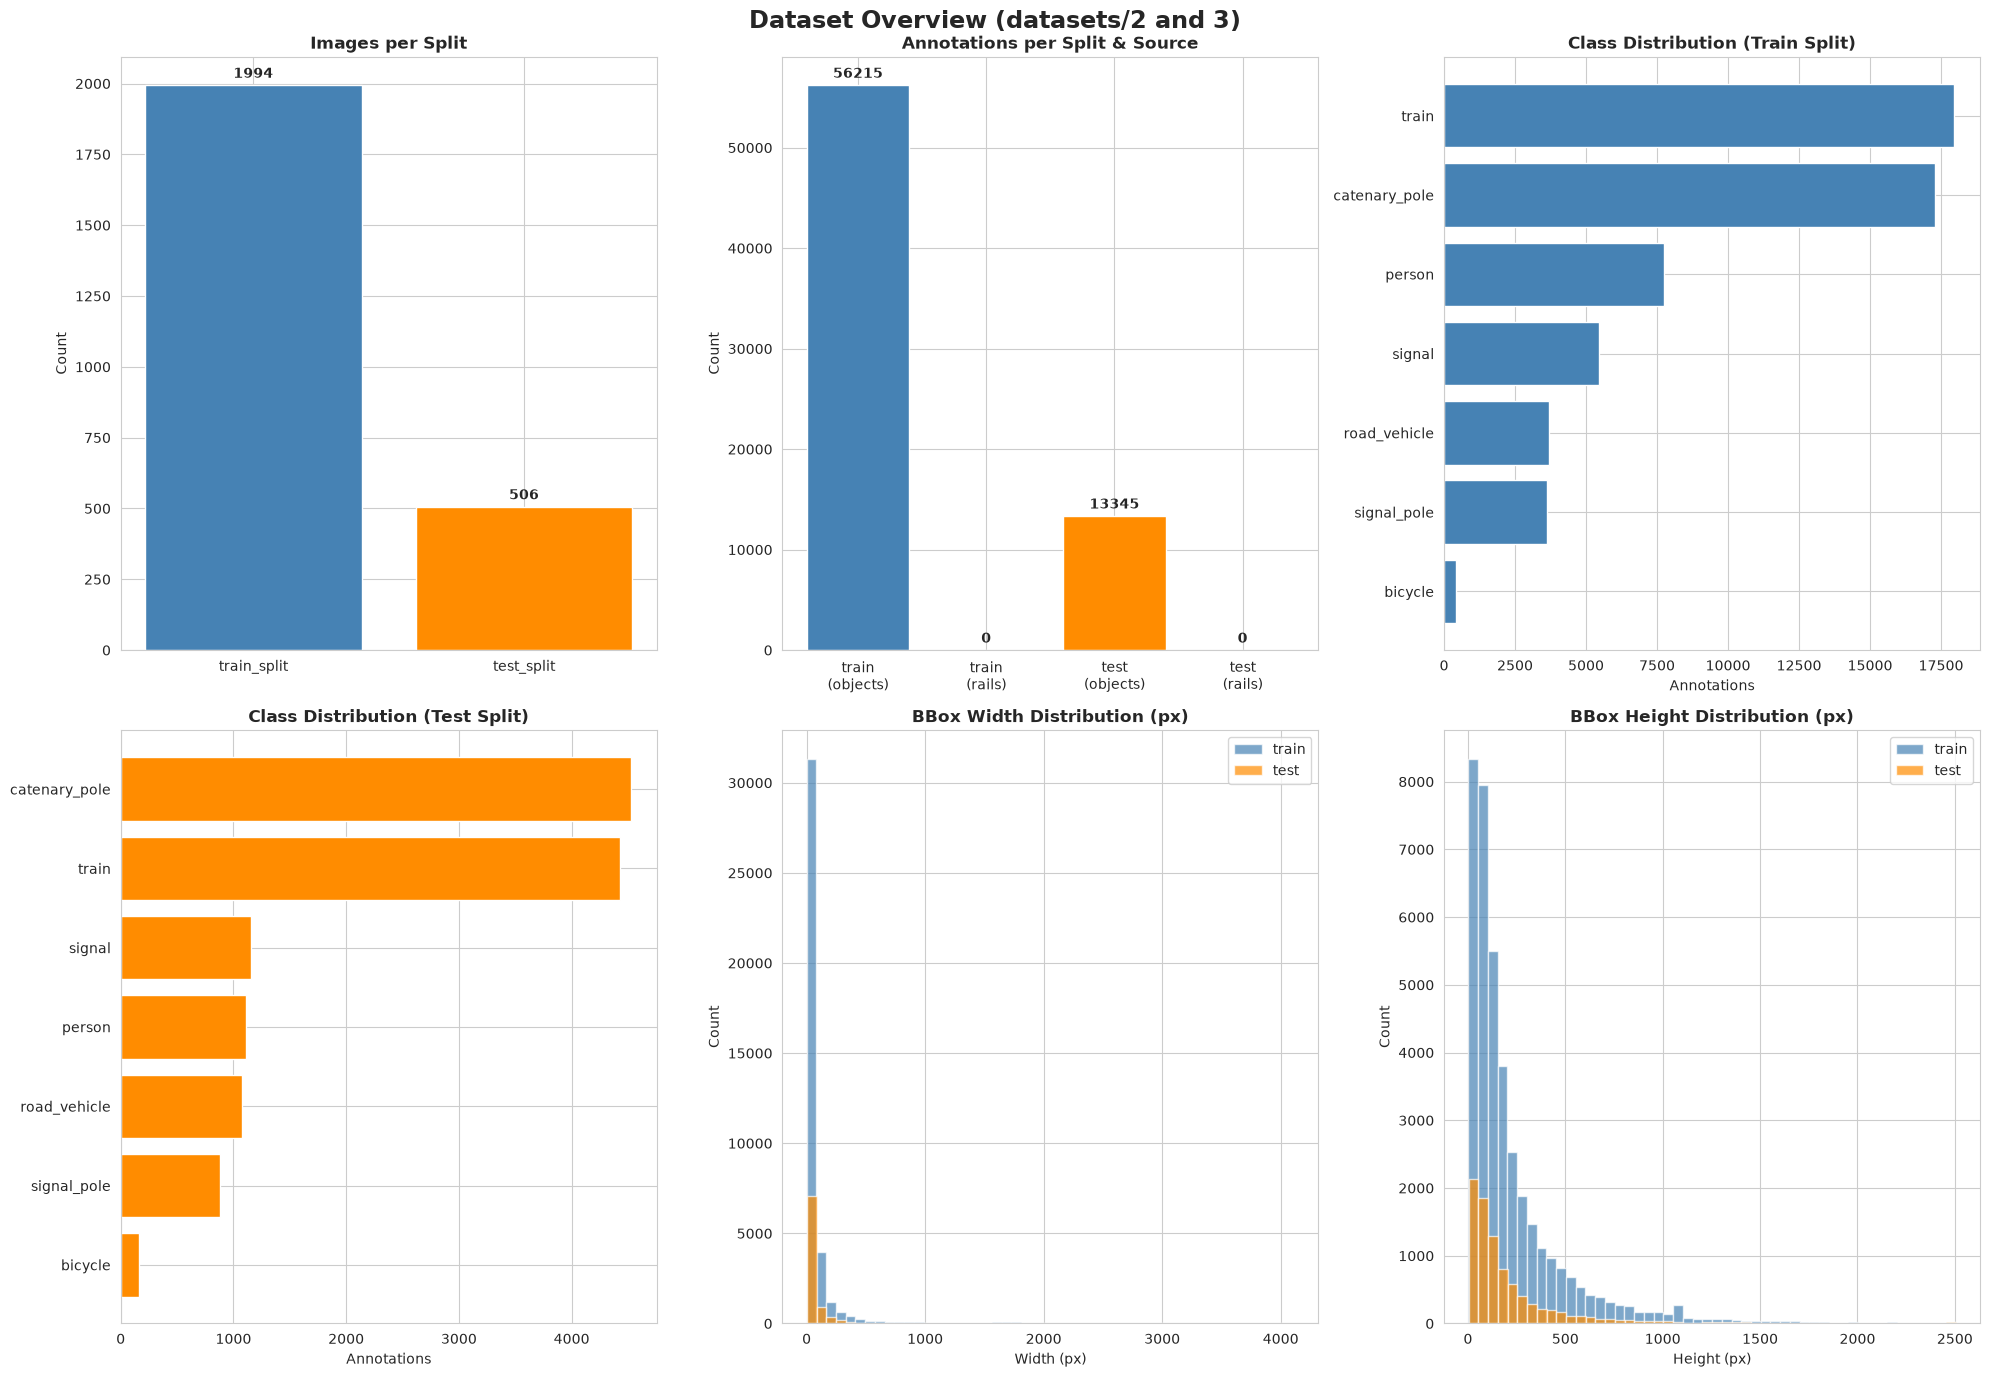

Chart saved to output/v3/dataset_overview.png


In [4]:
# Dataset charts: split sizes, class distributions, bbox size distributions
import numpy as np
from collections import Counter

def get_category_name_v2(cat_id, sources):
    for src in sources:
        for cat in src.get('categories', []):
            if cat['id'] == cat_id:
                return cat.get('name', f'cls_{cat_id}')
    return f'cls_{cat_id}'

cat_sources = [objects_train, rails_train]

def count_classes_v2(annotations_list):
    return Counter(
        get_category_name_v2(a['category_id'], cat_sources)
        for a in annotations_list if 'category_id' in a
    )

def bbox_dims_v2(annotations_list):
    ws, hs = [], []
    for a in annotations_list:
        if 'bbox' in a:
            _, _, w, h = a['bbox']
            ws.append(w); hs.append(h)
    return ws, hs

train_anns = objects_train.get('annotations', []) + rails_train.get('annotations', [])
test_anns  = objects_val.get('annotations', [])   + rails_val.get('annotations', [])

train_cls_counts = count_classes_v2(train_anns)
test_cls_counts  = count_classes_v2(test_anns)

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Dataset Overview (datasets/2 and 3)', fontsize=17, fontweight='bold')

# 1. Image count per split
ax1 = fig.add_subplot(2, 3, 1)
split_labels = ['train_split', 'test_split']
split_counts = [
    len(list(train_split_images_dir.glob('*'))) if train_split_images_dir.exists() else 0,
    len(list(test_split_images_dir.glob('*')))  if test_split_images_dir.exists()  else 0,
]
bars = ax1.bar(split_labels, split_counts, color=['steelblue', 'darkorange'])
ax1.bar_label(bars, padding=3, fontweight='bold')
ax1.set_title('Images per Split', fontweight='bold')
ax1.set_ylabel('Count')

# 2. Annotations per split & source
ax2 = fig.add_subplot(2, 3, 2)
ann_labels = ['train\n(objects)', 'train\n(rails)', 'test\n(objects)', 'test\n(rails)']
ann_counts = [
    len(objects_train.get('annotations', [])),
    len(rails_train.get('annotations', [])),
    len(objects_val.get('annotations', [])),
    len(rails_val.get('annotations', [])),
]
bars2 = ax2.bar(ann_labels, ann_counts, color=['steelblue', 'cornflowerblue', 'darkorange', 'moccasin'])
ax2.bar_label(bars2, padding=3, fontweight='bold')
ax2.set_title('Annotations per Split & Source', fontweight='bold')
ax2.set_ylabel('Count')

# 3. Class distribution – train
ax3 = fig.add_subplot(2, 3, 3)
if train_cls_counts:
    n3, v3 = zip(*sorted(train_cls_counts.items(), key=lambda x: -x[1]))
    ax3.barh(n3, v3, color='steelblue')
    ax3.set_title('Class Distribution (Train Split)', fontweight='bold')
    ax3.set_xlabel('Annotations')
    ax3.invert_yaxis()

# 4. Class distribution – test
ax4 = fig.add_subplot(2, 3, 4)
if test_cls_counts:
    n4, v4 = zip(*sorted(test_cls_counts.items(), key=lambda x: -x[1]))
    ax4.barh(n4, v4, color='darkorange')
    ax4.set_title('Class Distribution (Test Split)', fontweight='bold')
    ax4.set_xlabel('Annotations')
    ax4.invert_yaxis()

# 5. BBox width distribution
ax5 = fig.add_subplot(2, 3, 5)
tw, th = bbox_dims_v2(train_anns)
vw, vh = bbox_dims_v2(test_anns)
if tw: ax5.hist(tw, bins=50, alpha=0.7, color='steelblue', label='train')
if vw: ax5.hist(vw, bins=50, alpha=0.7, color='darkorange', label='test')
ax5.set_title('BBox Width Distribution (px)', fontweight='bold')
ax5.set_xlabel('Width (px)'); ax5.set_ylabel('Count'); ax5.legend()

# 6. BBox height distribution
ax6 = fig.add_subplot(2, 3, 6)
if th: ax6.hist(th, bins=50, alpha=0.7, color='steelblue', label='train')
if vh: ax6.hist(vh, bins=50, alpha=0.7, color='darkorange', label='test')
ax6.set_title('BBox Height Distribution (px)', fontweight='bold')
ax6.set_xlabel('Height (px)'); ax6.set_ylabel('Count'); ax6.legend()

plt.tight_layout()
Path('output/v3').mkdir(parents=True, exist_ok=True)
plt.savefig(Path('output/v3') / 'dataset_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved to output/v3/dataset_overview.png")

## 5. Convert COCO Format to YOLO Format

YOLO requires data in a specific format. We'll convert the COCO format annotations to YOLO format.

In [5]:
def coco_to_yolo_format(coco_data, output_dir):
    """
    Convert COCO format annotations to YOLO format.
    YOLO format: one .txt file per image with class_id x_center y_center width height
    (all values normalized to 0-1)
    
    Args:
        coco_data: COCO format dict with 'images' and 'annotations' keys
        output_dir: directory to save YOLO format labels
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Create image_id to image mapping for getting dimensions and filenames
    image_info = {}
    if 'images' in coco_data:
        for img in coco_data['images']:
            image_info[img['id']] = {
                'width': img.get('width', 640),
                'height': img.get('height', 480),
                'file_name': img.get('file_name', ''),
                'img_id': img['id']
            }
    
    # Dictionary to store annotations per image (using filename)
    image_annotations = {}
    
    # Process annotations
    skipped = 0
    if 'annotations' in coco_data:
        for annotation in coco_data['annotations']:
            # Skip annotations without bbox
            if 'bbox' not in annotation:
                skipped += 1
                continue
                
            img_id = annotation['image_id']
            category_id = annotation['category_id']
            bbox = annotation['bbox']  # [x, y, width, height]
            
            # Get image dimensions and filename
            if img_id in image_info:
                img_info = image_info[img_id]
                img_width = img_info['width']
                img_height = img_info['height']
                file_name = Path(img_info['file_name']).stem  # Get filename without extension
                
                # Convert bbox from COCO format to YOLO format
                x_min, y_min, box_width, box_height = bbox
                x_center = (x_min + box_width / 2) / img_width
                y_center = (y_min + box_height / 2) / img_height
                norm_width = box_width / img_width
                norm_height = box_height / img_height
                
                # Clamp values to [0, 1] range
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                norm_width = max(0, min(1, norm_width))
                norm_height = max(0, min(1, norm_height))
                
                # Store annotation
                if file_name not in image_annotations:
                    image_annotations[file_name] = []
                image_annotations[file_name].append(
                    f"{category_id} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}"
                )
    
    # Write label files
    for file_name, annotations in image_annotations.items():
        label_file = output_dir / f"{file_name}.txt"
        with open(label_file, 'w') as f:
            f.write('\n'.join(annotations) + '\n')
    
    label_count = len(image_annotations)
    return label_count, skipped

# Show COCO structure before conversion
coco_preview = {
    'images_sample': objects_train.get('images', [{}])[0] if 'images' in objects_train else 'N/A',
    'annotations_sample': objects_train.get('annotations', [{}])[0] if 'annotations' in objects_train else 'N/A',
    'categories': objects_train.get('categories', []) if 'categories' in objects_train else 'N/A'
}

## 6. Create YOLO Dataset Configuration

In [6]:
# Scan all annotation files to see what class IDs actually exist
all_class_ids_in_data = set()

# Scan objects annotations
for annotation in objects_train.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids_in_data.add(annotation['category_id'])

for annotation in objects_val.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids_in_data.add(annotation['category_id'])

# Scan rails annotations
for annotation in rails_train.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids_in_data.add(annotation['category_id'])

for annotation in rails_val.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids_in_data.add(annotation['category_id'])

unique_class_ids_in_data = sorted(all_class_ids_in_data)
max_class_id_in_data = max(all_class_ids_in_data) if all_class_ids_in_data else None

# Delete cache files to force YOLO to reload
cache_files = list((dataset_root / 'labels').glob('*.cache'))
for cache_file in cache_files:
    try:
        cache_file.unlink()
    except Exception:
        pass

In [7]:
# Create YOLO-formatted labels directory
labels_train_dir = dataset_root / 'labels' / 'train_split'
labels_val_dir = dataset_root / 'labels' / 'test_split'

labels_train_dir.mkdir(parents=True, exist_ok=True)
labels_val_dir.mkdir(parents=True, exist_ok=True)
for existing_label in labels_train_dir.glob('*.txt'):
    existing_label.unlink()
for existing_label in labels_val_dir.glob('*.txt'):
    existing_label.unlink()

# Convert annotations to YOLO format
objects_train_stats = coco_to_yolo_format(objects_train, labels_train_dir)
objects_val_stats = coco_to_yolo_format(objects_val, labels_val_dir)
rails_train_stats = coco_to_yolo_format(rails_train, labels_train_dir)
rails_val_stats = coco_to_yolo_format(rails_val, labels_val_dir)

# Build comprehensive class mapping from both sources
class_names_map = {}

if 'categories' in objects_train:
    for cat in objects_train['categories']:
        cat_id = cat.get('id')
        cat_name = cat.get('name', f'class_{cat_id}')
        if cat_id not in class_names_map:
            class_names_map[cat_id] = cat_name

if 'categories' in rails_train:
    for cat in rails_train['categories']:
        cat_id = cat.get('id')
        cat_name = cat.get('name', f'class_{cat_id}')
        if cat_id not in class_names_map:
            class_names_map[cat_id] = cat_name

# Scan all annotations to find all class IDs actually used
all_class_ids = set()

for annotation in objects_train.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids.add(annotation['category_id'])

for annotation in objects_val.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids.add(annotation['category_id'])

for annotation in rails_train.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids.add(annotation['category_id'])

for annotation in rails_val.get('annotations', []):
    if 'category_id' in annotation:
        all_class_ids.add(annotation['category_id'])

# Create ordered class list covering all class IDs from 0 to max
sorted_class_ids = sorted(list(all_class_ids))
max_class_id = max(sorted_class_ids) if sorted_class_ids else 0
num_classes = max_class_id + 1  # YOLO expects 0 to num_classes-1

# Build names list with proper indexing
class_list = []
for i in range(num_classes):
    if i in class_names_map:
        class_list.append(class_names_map[i])
    else:
        class_list.append(f'class_{i}')

# Create data.yaml for YOLO training
yolo_config = {
    'path': str(dataset_root.absolute()),
    'train': 'images/train_split',
    'val': 'images/test_split',
    'test': 'images/test_split',
    'nc': num_classes,
    'names': class_list
}

# Install PyYAML if needed and write the configuration file
try:
    import yaml
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'pyyaml'])
    import yaml

# Delete old data.yaml if it exists
yaml_path = dataset_root / 'data.yaml'
if yaml_path.exists():
    yaml_path.unlink()

# Write new data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False)

with open(yaml_path, 'r') as f:
    data_yaml_content = f.read()

--- Running Path Diagnostic Checks ---
✅ Image directory exists: '/home/jovyan/datasets/4/images/test_split'
📊 Total files found in image directory: 506
📂 First 3 files found: ['img_936_train.png', 'img_695_train.png', 'img_892_train.png']
✅ Label directory exists: '/home/jovyan/datasets/4/labels/test_split'

--- Running Bounding Box Visualization ---
📸 Image selected: 'img_936_train.png'
🔍 Corresponding label expected at: '/home/jovyan/datasets/4/labels/test_split/img_936_train.txt'
📏 Image Dimensions: 4112x2504
🏷️ Label file found! Drawing boxes...
🎨 Success: Drew 1 box(es). Generating plot...


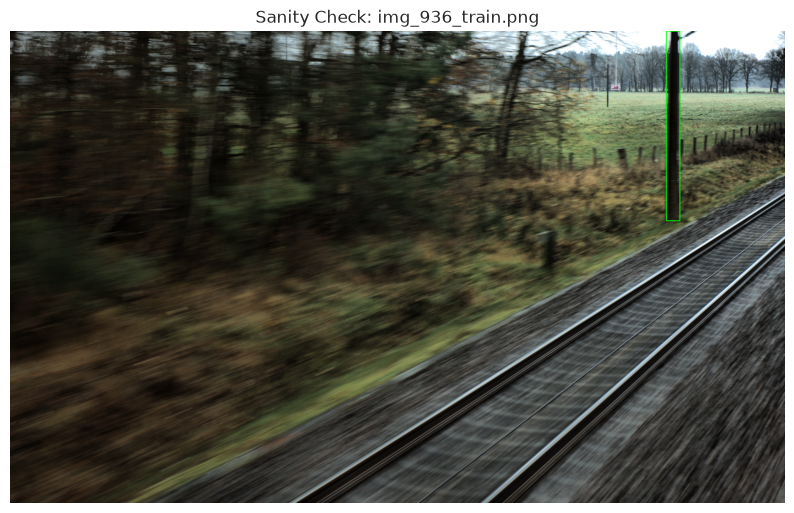

🏁 Plot successfully rendered.


In [8]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import os

# 1. Paths set exactly as verified by your YAML file
test_img_dir = '/home/jovyan/datasets/4/images/test_split'
test_lbl_dir = '/home/jovyan/datasets/4/labels/test_split'

print("--- Running Path Diagnostic Checks ---")

# Verify image directory
if not os.path.exists(test_img_dir):
    print(f"❌ ERROR: Image directory does not exist: '{test_img_dir}'")
else:
    all_files = os.listdir(test_img_dir)
    print(f"✅ Image directory exists: '{test_img_dir}'")
    print(f"📊 Total files found in image directory: {len(all_files)}")
    if len(all_files) > 0:
        print(f"📂 First 3 files found: {all_files[:3]}")
    else:
        print("⚠️ WARNING: The image directory is completely empty!")

# Verify label directory
if not os.path.exists(test_lbl_dir):
    print(f"❌ ERROR: Label directory does not exist: '{test_lbl_dir}'")
else:
    print(f"✅ Label directory exists: '{test_lbl_dir}'")

print("\n--- Running Bounding Box Visualization ---")

# Grab files supporting multiple formats case-insensitively (.jpg, .jpeg, .png, .JPG, etc.)
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
sample_images = []
if os.path.exists(test_img_dir):
    sample_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(valid_extensions)]

if not sample_images:
    print("❌ ERROR: No images found with valid extensions (.jpg, .jpeg, .png) in your folder!")
else:
    # Use the first image
    target_img_name = sample_images[0]
    img_path = os.path.join(test_img_dir, target_img_name)
    
    # Robustly swap image extension for .txt (e.g. 'img.JPG' -> 'img.txt')
    filename_without_ext, _ = os.path.splitext(target_img_name)
    lbl_path = os.path.join(test_lbl_dir, f"{filename_without_ext}.txt")
    
    print(f"📸 Image selected: '{target_img_name}'")
    print(f"🔍 Corresponding label expected at: '{lbl_path}'")
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ ERROR: OpenCV failed to load image at '{img_path}'. File might be corrupted.")
    else:
        h, w, _ = img.shape
        print(f"📏 Image Dimensions: {w}x{h}")
        
        if os.path.exists(lbl_path):
            print("🏷️ Label file found! Drawing boxes...")
            boxes_drawn = 0
            with open(lbl_path, 'r') as f:
                for line_idx, line in enumerate(f.readlines(), 1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        print(f"⚠️ Warning: Line {line_idx} is malformed: '{line.strip()}'")
                        continue
                    
                    try:
                        cls, x, y, nw, nh = map(float, parts)
                        # Convert YOLO normalized format back to pixel coordinates
                        x1 = int((x - nw/2) * w)
                        y1 = int((y - nh/2) * h)
                        x2 = int((x + nw/2) * w)
                        y2 = int((y + nh/2) * h)
                        
                        # Draw bounding box (Green, thickness=3)
                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                        boxes_drawn += 1
                    except ValueError as e:
                        print(f"⚠️ Error parsing line {line_idx}: {e}")
            
            print(f"🎨 Success: Drew {boxes_drawn} box(es). Generating plot...")
            
            # Display image and bounding boxes inline
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"Sanity Check: {target_img_name}")
            plt.axis('off')
            plt.show()
            print("🏁 Plot successfully rendered.")
        else:
            print(f"❌ ERROR: Label file not found at '{lbl_path}'. Drawing image without boxes.")
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"Sanity Check (No Label): {target_img_name}")
            plt.axis('off')
            plt.show()

## 7. Initialize and Configure YOLO Model

In [ ]:
from ultralytics import YOLO
import torch

# 1. Clear VRAM cache completely
torch.cuda.empty_cache()

# 2. Load the Large Model Backbone
model = YOLO('yolov8l.pt')

# 3. Train with optimized settings (allowing YOLO to auto-accumulate gradients)
results = model.train(
    data='/home/jovyan/datasets/4/data.yaml',
    epochs=30,               
    imgsz=960,               # Keep 960 to preserve high-res details of small objects
    batch=4,                 # Safe batch size to prevent TaskAlignedAssigner VRAM fallback
    device=0,
    
    # --- REGULARIZATION TO DEFEAT OVERFITTING ---
    mixup=0.2,               
    scale=0.6,               
    mosaic=1.0,              
    
    # --- RECALL-FOCUSED LOSS TUNING ---
    cls=1.5,                 
    box=8.5,                 
    
    save=True,
    plots=True
)

# 4. Safely display model parameter count on finish
if hasattr(model, 'model'):
    model_parameters = sum(p.numel() for p in model.model.parameters())
    print(f"\n✅ Training complete! Total model parameters: {model_parameters:,}")
else:
    print("\n✅ Training complete!")

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.92 🚀 Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10823MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=8.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jovyan/datasets/4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8l.pt, momentum=0.93

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



       9/30      6.92G      2.057       3.91      1.254         93        960: 100% ━━━━━━━━━━━━ 499/499 4.2it/s 1:580.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.2it/s 8.9s0.1s
                   all        506       8886      0.485        0.3      0.278      0.137

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/30      6.37G      2.053      3.903      1.248         78        960: 100% ━━━━━━━━━━━━ 499/499 4.2it/s 1:580.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.5it/s 8.5s0.1s
                   all        506       8886      0.623      0.283      0.288      0.145

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/30      6.28G      2.006      3.709      1.223         52        960: 100% ━━━━━━━━━━━━ 499/499 4.2it/s 1:580.2sss
                 Class     Imag

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



      28/30      6.24G      1.631      2.555      1.075          2        960: 100% ━━━━━━━━━━━━ 499/499 4.3it/s 1:570.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.4it/s 8.6s0.1s
                   all        506       8886      0.593      0.353       0.37      0.197

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      6.17G      1.619      2.505      1.064         44        960: 87% ━━━━━━━━━━── 436/499 4.2it/s 1:42<15.1ss

In [ ]:
# Print the exact paths to your saved weights
print("🏆 Best weights (use these for testing):")
print(model.trainer.best)

print("\n⏱️ Last weights (use to resume training if needed):")
print(model.trainer.last)

## 9. Evaluate Model Performance

In [ ]:
# Evaluate on validation set
metrics = model.val(
    data=str(dataset_root / 'data.yaml'),
    imgsz=640,
    device=0
)

confusion_matrix = None
if hasattr(metrics, 'confusion_matrix') and hasattr(metrics.confusion_matrix, 'matrix'):
    confusion_matrix = metrics.confusion_matrix.matrix

accuracy = None
if confusion_matrix is not None:
    total_predictions = sum(sum(row) for row in confusion_matrix)
    correct_predictions = sum(
        row[index]
        for index, row in enumerate(confusion_matrix)
        if index < len(row)
    )
    accuracy = correct_predictions / total_predictions if total_predictions else 0.0

validation_metrics = {
    'accuracy': accuracy,
    'mAP50': metrics.box.map50,
    'mAP50-95': metrics.box.map
}

validation_metrics_path = output_root / 'validation_metrics.txt'
with open(validation_metrics_path, 'w') as f:
    f.write(f"Validation Accuracy: {accuracy:.4f}\n" if accuracy is not None else 'Validation Accuracy: unavailable\n')
    f.write(f"mAP50: {metrics.box.map50:.4f}\n")
    f.write(f"mAP50-95: {metrics.box.map:.4f}\n")
    f.write('Confusion Matrix:\n')
    f.write(f"{confusion_matrix if confusion_matrix is not None else 'unavailable'}\n")

print(f"Validation Accuracy: {accuracy:.4f}" if accuracy is not None else 'Validation Accuracy: unavailable')
print('Confusion Matrix:')
print(confusion_matrix if confusion_matrix is not None else 'unavailable')

In [ ]:

# Validation results charts: confusion matrix heatmap + per-class metrics
class_labels = class_list  # defined in section 6

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Validation Results', fontsize=16, fontweight='bold')

# --- Confusion matrix heatmap ---
if confusion_matrix is not None:
    cm = np.array(confusion_matrix)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0)

    tick_labels = class_labels + ['background'] if len(class_labels) == cm.shape[0] - 1 else \
                  [str(i) for i in range(cm.shape[0])]

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=tick_labels, yticklabels=tick_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Confusion Matrix (row-normalised)', fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'Confusion matrix unavailable', ha='center', va='center')

# --- Per-class precision / recall / mAP50 bar chart ---
if hasattr(metrics, 'box') and hasattr(metrics.box, 'ap_class_index'):
    ap_class_idx   = metrics.box.ap_class_index
    per_class_ap50 = metrics.box.ap50 if hasattr(metrics.box, 'ap50') else None
    per_class_p    = metrics.box.p    if hasattr(metrics.box, 'p')    else None
    per_class_r    = metrics.box.r    if hasattr(metrics.box, 'r')    else None

    names = [class_labels[i] if i < len(class_labels) else f'cls_{i}' for i in ap_class_idx]
    x = range(len(names))
    width = 0.28

    if per_class_p    is not None: axes[1].bar([i - width for i in x], per_class_p,    width, label='Precision', color='steelblue')
    if per_class_r    is not None: axes[1].bar(list(x),                  per_class_r,    width, label='Recall',    color='darkorange')
    if per_class_ap50 is not None: axes[1].bar([i + width for i in x], per_class_ap50, width, label='mAP50',     color='green')

    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(names, rotation=35, ha='right')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Per-Class Precision / Recall / mAP50', fontweight='bold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Per-class metrics unavailable', ha='center', va='center')

plt.tight_layout()
plt.savefig(output_root / 'validation_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Chart saved to {output_root / 'validation_results.png'}")


## 10. Test the Model

In [ ]:
# Run inference on test set
results = model.predict(
    source=str(test_split_images_dir),
    imgsz=640,
    device=0,
    conf=0.5,  # confidence threshold
    save=True,
    project=str(yolo_output_dir),
    name='test_predictions'
)

test_prediction_count = len(results)

## 11. Visualize Training Results

In [ ]:
# Locate model artifacts
runs_dir = yolo_output_dir

all_pt_files = list(runs_dir.rglob('*.pt'))
all_results_png = list(runs_dir.rglob('results.png'))
all_results_csv = list(runs_dir.rglob('results.csv'))

if all_pt_files:
    best_pt_candidates = [f for f in all_pt_files if 'best.pt' in f.name]
    if best_pt_candidates:
        best_model_path = sorted(best_pt_candidates, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        try:
            best_model = YOLO(str(best_model_path))
        except Exception:
            best_model = None
    else:
        most_recent_pt = sorted(all_pt_files, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        try:
            best_model = YOLO(str(most_recent_pt))
        except Exception:
            best_model = None
else:
    best_model = None

In [ ]:

# Training metrics charts from results.csv
import pandas as pd

results_csv_candidates = list(yolo_output_dir.rglob('results.csv'))
if results_csv_candidates:
    results_csv_path = sorted(results_csv_candidates, key=lambda x: x.stat().st_mtime, reverse=True)[0]
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    epochs = df['epoch'] if 'epoch' in df.columns else range(len(df))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Metrics Over Epochs', fontsize=16, fontweight='bold')

    for col, ax, title in [
        ('train/box_loss', axes[0, 0], 'Train Box Loss'),
        ('train/cls_loss', axes[0, 1], 'Train Class Loss'),
        ('train/dfl_loss', axes[0, 2], 'Train DFL Loss'),
        ('val/box_loss',   axes[1, 0], 'Val Box Loss'),
        ('val/cls_loss',   axes[1, 1], 'Val Class Loss'),
    ]:
        if col in df.columns:
            ax.plot(epochs, df[col], linewidth=2, color='steelblue')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

    ax_map = axes[1, 2]
    if 'metrics/mAP50(B)' in df.columns:
        ax_map.plot(epochs, df['metrics/mAP50(B)'],    label='mAP50',    linewidth=2, color='green')
    if 'metrics/mAP50-95(B)' in df.columns:
        ax_map.plot(epochs, df['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='darkorange')
    ax_map.set_title('mAP Over Epochs', fontweight='bold')
    ax_map.set_xlabel('Epoch'); ax_map.set_ylabel('mAP'); ax_map.legend()

    plt.tight_layout()
    plt.savefig(output_root / 'training_metrics.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Chart saved to {output_root / 'training_metrics.png'}")
else:
    print("results.csv not found — run training first.")


## 12. Save and Export Model

In [ ]:
# Load or confirm best model is loaded
if 'best_model' not in locals() or best_model is None:
    runs_base = yolo_output_dir
    all_pt_files = list(runs_base.rglob('best.pt'))

    if not all_pt_files:
        all_pt_files = list(runs_base.rglob('*.pt'))

    if all_pt_files:
        best_model_path = sorted(all_pt_files, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        try:
            best_model = YOLO(str(best_model_path))
            best_model_size_mb = best_model_path.stat().st_size / (1024 * 1024)
        except Exception:
            best_model = None
            best_model_size_mb = None
    else:
        best_model = None
        best_model_size_mb = None

best_model_loaded = best_model is not None

## 13. Run Inference on Single Image

In [ ]:
# Example: Run inference on a single image
test_image_path = list(test_split_images_dir.glob('*'))[0] if list(test_split_images_dir.glob('*')) else None

if 'best_model' not in locals() or best_model is None:
    inference_result = None
elif test_image_path:
    results = best_model.predict(
        source=str(test_image_path),
        imgsz=640,
        device=0,
        conf=0.5
    )
    result = results[0]
    annotated_img = result.plot()  # Returns BGR numpy array
    output_path = output_root / 'inference_result.png'
    cv2.imwrite(str(output_path), annotated_img)
    img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'YOLO Detection Result - {len(result.boxes)} Detections Found', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_root / 'inference_visualization.png', dpi=100, bbox_inches='tight')
    plt.show()
    inference_result = result
else:
    inference_result = None

## 14. Summary and Next Steps

In [ ]:
# Export the trained model to alternative formats
model_export_ready = 'best_model' in locals() and best_model is not None

if model_export_ready:
    model_export_summary = {
        'torch_pt': str(output_root / 'yolo_training*' / 'weights' / 'best.pt'),
        'onnx': 'available',
        'torchscript': 'available'
    }
else:
    model_export_summary = {
        'error': 'Best model not loaded. Run the model loading cell first.'
    }

In [ ]:
model_training_summary = {
    'dataset_path': str(dataset_root.absolute()),
    'training_images': len(list(train_split_images_dir.glob('*'))),
    'validation_images': len(list(test_split_images_dir.glob('*'))),
    'test_images': len(list(test_split_images_dir.glob('*'))),
    'target_split': {'train': train_target_count, 'test': test_target_count}
}

runs_base = yolo_output_dir
training_dirs = sorted([d for d in runs_base.glob('yolo_training*') if d.is_dir()],
                       key=lambda x: x.stat().st_mtime, reverse=True)

if training_dirs:
    latest_training_dir = training_dirs[0]
    best_model_path = latest_training_dir / 'weights' / 'best.pt'
    last_model_path = latest_training_dir / 'weights' / 'last.pt'
    training_results = {
        'model': 'YOLOv8 Medium',
        'output_directory': str(latest_training_dir),
        'results_png': str(latest_training_dir / 'results.png') if (latest_training_dir / 'results.png').exists() else None,
        'results_csv': str(latest_training_dir / 'results.csv') if (latest_training_dir / 'results.csv').exists() else None,
        'best_model': str(best_model_path) if best_model_path.exists() else None,
        'last_model': str(last_model_path) if last_model_path.exists() else None,
    }
else:
    training_results = {
        'model': 'YOLOv8 Medium',
        'output_directory': None,
        'results_png': None,
        'results_csv': None,
        'best_model': None,
        'last_model': None,
    }

next_steps = [
    'Run the model loading cell',
    'Run single-image inference',
    'Export the model to the desired format',
    'Deploy the model to production'
 ]
summary_ready = True